### 1. Import all needed modules and define constants

In [34]:
import numpy as np
from tensorflow.keras.datasets import mnist
import keras
import sys
import matplotlib.pyplot as plt

NB_CLASSES = 10
NB_INPUTS = 784 # 28x28

### 2. Import the data

In [37]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [38]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


### 3. Images display

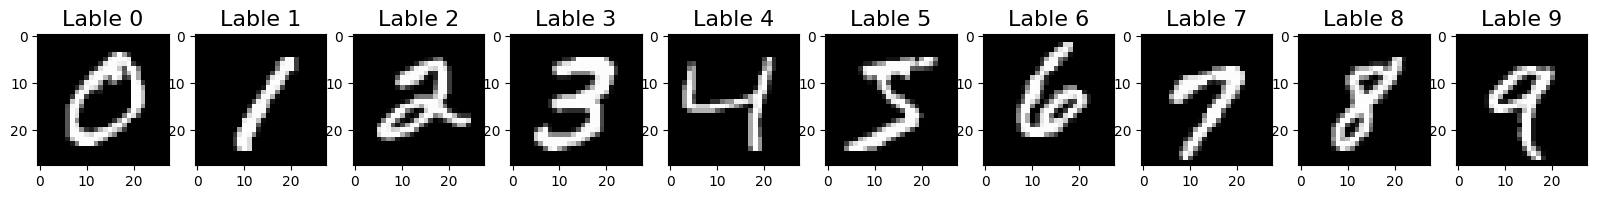

In [39]:
f, ax = plt.subplots(1, NB_CLASSES, figsize=(20,20))

for i in range(0, NB_CLASSES):
    sample = x_train[y_train == i][0]
    ax[i].imshow(sample, cmap='gray')
    ax[i].set_title(f'Lable {i}', fontsize=16)

In [40]:
image_index = 300
for row in x_train[image_index]:
    for pixel in row:
        sys.stdout.write(f'{pixel:3d} ')
    sys.stdout.write('\n')

  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 138 238 217  68   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 150 254 254 254 232   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0  63 224 254 145 254 240  22   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0  15 160 253 254 254 187 254 180   0   0   0   0 

### 4. One hot encoding the y data

In [41]:
y_train = keras.utils.to_categorical(y_train, NB_CLASSES)
y_test = keras.utils.to_categorical(y_test, NB_CLASSES)

### 5. Prepare x data

#### 5.1. Flatten the images _(28x28 vector -> 784x1)_

In [42]:
x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)

#### 5.2 Normalize the values _([0, 255] -> [0, 1])_

In [43]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [44]:
print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (60000, 784)
Test shape: (10000, 784)


---

In [ ]:
## Softmax
def softmax(x):
    x = x - np.max(x,axis=1,keepdims=True)
    expx = np.exp(x)
    return expx/np.sum(expx,axis=1,keepdims=True)

In [ ]:
## Log loss function
# On ajoute un epilon juste poupr eviter une erreur dans le cas ou on se retrouve avec : np.log(0) -> -inf
def loss(Y,P):
    eps=1e-12
    return -np.mean(np.sum(Y*np.log(P+eps),axis=1))